[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leippold/FinEng/blob/main/notebooks/01_Introduction.ipynb)

# Lecture 1: Introduction to Financial Engineering

**Course:** 22MO0142 -- Financial Engineering, Spring 2026 
**Instructor:** Prof. Markus Leippold, University of Zurich 
**Department:** Banking and Finance

---

## Learning Objectives

After completing this notebook, you should be able to:

1. **Explain** what financial engineering is and why it matters in modern finance.
2. **State and apply** the no-arbitrage principle and the Law of One Price.
3. **Compute** present values and discount factors using continuous compounding.
4. **Derive** the no-arbitrage forward price using cost-of-carry arguments.
5. **Plot and interpret** payoff diagrams for forwards, calls, and puts.
6. **Verify** put-call parity both algebraically and numerically.
7. **Construct** a simple static replicating portfolio.

---
## Setup

Run the cell below to import the required libraries. All packages used here are available by default in Google Colab.

In [1]:
# ============================================================
# Setup: imports and plotting configuration
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# Plotting defaults
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'lines.linewidth': 2.2,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print("Setup complete. NumPy version:", np.__version__)

Setup complete. NumPy version: 1.26.4


---
## 1. Motivation: Why Financial Engineering?

> *"The revolutionary idea that defines the boundary between modern times and the past is the mastery of risk: the notion that the future is more than a whim of the gods and that men and women are not passive before nature."* 
> -- Peter L. Bernstein, *Against the Gods* (1996)

Financial engineering stands at the intersection of **mathematics**, **economics**, and **computation**. Its central question is deceptively simple:

> **How do we price and hedge financial derivatives in a mathematically rigorous yet practically useful manner?**

### Real-world importance

- **Notional value of global derivatives** exceeds \$600 trillion (BIS, 2024). These contracts must be priced consistently every day.
- **Airlines** use fuel derivatives to hedge jet-fuel costs, stabilising ticket prices.
- **Pension funds** use interest rate swaps to match long-term liabilities.
- **Tech companies** use FX options to manage cross-currency revenue.
- The **2008 financial crisis** was, in part, a failure to properly model the risks embedded in complex structured products.

### Three pillars of financial engineering

| Pillar | Description |
|--------|-------------|
| **No-Arbitrage Pricing** | Prices are constrained by the absence of "free lunches" |
| **Replication** | Synthesising payoffs from traded instruments |
| **Risk-Neutral Valuation** | Computing expectations under the "right" probability measure |

The key insight of modern derivative pricing is that it is about **relative valuation** -- pricing one asset *in terms of* others -- not absolute valuation based on preferences or equilibrium.

---
## 2. Time Value of Money and Discount Factors

Before we can price any derivative, we need the language of **present value**.

### Continuous compounding

If the risk-free rate is $r$ (annualised, continuously compounded), then:

- **Future value** of \$1 invested today for $T$ years:
$$FV = e^{rT}$$

- **Present value** (PV) of \$1 received at time $T$:
$$PV = e^{-rT}$$

- The **discount factor** is:
$$D(0,T) = e^{-rT}$$

This is the price today of a **zero-coupon bond** paying \$1 at maturity $T$.

### Why continuous compounding?

With discrete compounding at frequency $n$ per year:
$$\left(1 + \frac{r}{n}\right)^{nT} \xrightarrow{n \to \infty} e^{rT}$$

Continuous compounding is the natural limit and makes the mathematics (especially calculus-based derivations) much cleaner.

In [2]:
# ============================================================
# Computing present values and discount factors
# ============================================================

r = 0.05          # risk-free rate (5% per annum)
T = np.array([0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 30.0])  # maturities in years

# Discount factors under continuous compounding
discount_factors = np.exp(-r * T)

print("Risk-free rate: r = {:.2%}".format(r))
print("="*45)
print(f"{'Maturity (yrs)':>15} {'Discount Factor':>17}")
print("-"*45)
for t_i, df_i in zip(T, discount_factors):
    print(f"{t_i:>15.2f} {df_i:>17.6f}")

Risk-free rate: r = 5.00%
 Maturity (yrs)   Discount Factor
---------------------------------------------
           0.25          0.987578
           0.50          0.975310
           1.00          0.951229
           2.00          0.904837
           5.00          0.778801
          10.00          0.606531
          30.00          0.223130


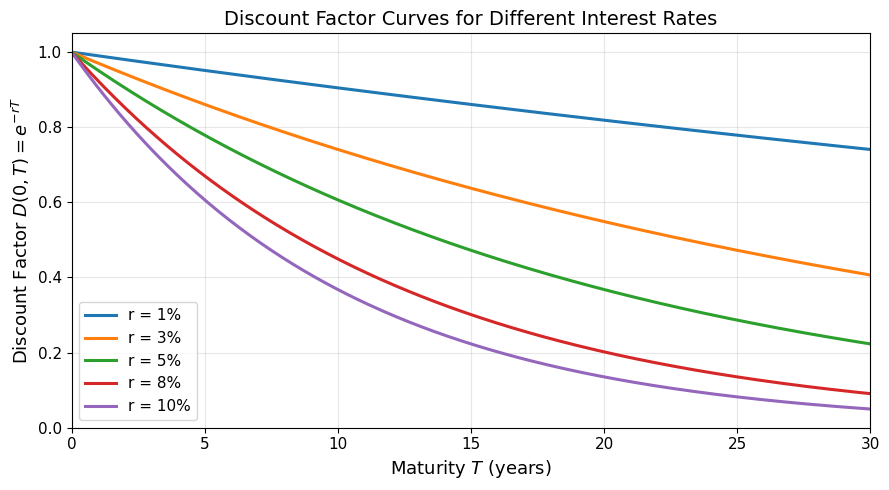

In [3]:
# ============================================================
# Visualise: discount factor curve and the effect of rates
# ============================================================

T_fine = np.linspace(0, 30, 300)
rates = [0.01, 0.03, 0.05, 0.08, 0.10]

fig, ax = plt.subplots(figsize=(9, 5))
for rate in rates:
    ax.plot(T_fine, np.exp(-rate * T_fine), label=f'r = {rate:.0%}')

ax.set_xlabel('Maturity $T$ (years)')
ax.set_ylabel('Discount Factor $D(0,T) = e^{-rT}$')
ax.set_title('Discount Factor Curves for Different Interest Rates')
ax.legend()
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 30)
plt.tight_layout()
plt.show()

**Observation:** Higher interest rates lead to smaller discount factors (i.e., future cash flows are worth less today). A dollar in 30 years at $r=10\%$ is worth only about 5 cents today.

---
## 3. The No-Arbitrage Principle

### What is arbitrage?

An **arbitrage** is a self-financing trading strategy $\pi$ such that:

1. $V_0(\pi) = 0$ -- zero initial investment,
2. $V_T(\pi) \geq 0$ almost surely -- no risk of loss,
3. $\mathbb{P}(V_T(\pi) > 0) > 0$ -- positive probability of profit.

In plain language: **a risk-free profit from nothing**.

A market satisfies the **no-arbitrage condition (NA)** if no such strategy exists.

### Standard frictionless market assumptions

- Assets are infinitely divisible.
- Short selling is unrestricted.
- No bid-ask spread, transaction costs, or taxes.
- Borrowing and lending at the same risk-free rate $r$.

These are unrealistic but form a clean benchmark. In liquid markets, they are a reasonable first approximation.

### Why does no-arbitrage hold (approximately)?

In practice, thousands of traders constantly scan for arbitrage. Any mispricing is exploited almost instantly, pushing prices back to no-arbitrage levels. This is the economic content of the **Efficient Market Hypothesis**.

---
## 4. The Law of One Price

A direct consequence of no-arbitrage:

> **Theorem (Law of One Price).** If two portfolios $\pi_1$ and $\pi_2$ have identical payoffs at maturity, $V_T(\pi_1) = V_T(\pi_2)$ almost surely, then they must have the same price at every earlier time:
> $$V_t(\pi_1) = V_t(\pi_2) \quad \text{for all } t \leq T.$$

**Proof sketch.** Suppose $V_t(\pi_1) > V_t(\pi_2)$. Then at time $t$:
- Sell $\pi_1$ (receive $V_t(\pi_1)$) and buy $\pi_2$ (pay $V_t(\pi_2)$).
- Pocket $V_t(\pi_1) - V_t(\pi_2) > 0$.
- At maturity, $\pi_2$ delivers $V_T(\pi_2) = V_T(\pi_1)$, which covers the obligation from selling $\pi_1$.

Result: positive profit, zero future liability. This is an arbitrage. Contradiction. $\square$

### Implication for pricing

If we can **replicate** a derivative's payoff using traded instruments, then the derivative's price **must** equal the cost of the replicating portfolio. This is the foundation of all replication-based pricing.

---
## 5. Forward Contracts

### Definition

A **forward contract** is an obligation to buy (long) or sell (short) an asset $S$ at a pre-agreed price $K$ at maturity $T$.

**Payoff at maturity:**
$$\text{Long forward: } S_T - K, \qquad \text{Short forward: } K - S_T$$

Key properties:
- Both parties are **obligated** (unlike options).
- The forward price $K = F_{0,T}$ is chosen so the contract has **zero initial value**.
- The payoff is **linear** in $S_T$.

### No-arbitrage forward price

**Two strategies to own one share at time $T$:**

| | Strategy A: Buy forward | Strategy B: Buy and hold |
|--|--|--|
| **At $t=0$** | Enter forward (cost 0), invest $Ke^{-rT}$ in bonds | Buy stock for $S_0$ |
| **At $T$** | Bonds grow to $K$; pay $K$ via forward, receive stock | Own stock |
| **Net at $T$** | Own stock | Own stock |

Both deliver one share at $T$. By the Law of One Price:
$$Ke^{-rT} = S_0 \quad \Longrightarrow \quad \boxed{F_{0,T} = S_0 \, e^{rT}}$$

More generally, at time $t$ for delivery at $T$:
$$F_{t,T} = S_t \, e^{r(T-t)}$$

With a continuous dividend yield $q$:
$$F_{t,T} = S_t \, e^{(r-q)(T-t)}$$

**Crucial point:** Forward pricing requires **no probability model** -- it is a pure no-arbitrage and cost-of-carry argument.

In [4]:
# ============================================================
# Forward pricing: no-arbitrage price and arbitrage check
# ============================================================

S0 = 100.0        # current stock price
r  = 0.05          # risk-free rate
T  = 1.0           # maturity (1 year)
q  = 0.02          # continuous dividend yield

# No-arbitrage forward prices
F_no_div = S0 * np.exp(r * T)
F_with_div = S0 * np.exp((r - q) * T)

print("Forward Pricing (No-Arbitrage)")
print("=" * 45)
print(f"  Spot price S0           = {S0:>10.2f}")
print(f"  Risk-free rate r        = {r:>10.2%}")
print(f"  Maturity T              = {T:>10.2f} years")
print(f"  Dividend yield q        = {q:>10.2%}")
print("-" * 45)
print(f"  Forward (no dividends)  = {F_no_div:>10.4f}")
print(f"  Forward (with div yield)= {F_with_div:>10.4f}")

# ----- Arbitrage example -----
F_market = 108.0   # suppose the market quotes this forward price
F_fair   = F_no_div

print("\n--- Arbitrage Check ---")
print(f"  Market forward price    = {F_market:.4f}")
print(f"  Fair forward price      = {F_fair:.4f}")
if abs(F_market - F_fair) < 1e-8:
    print("  => No arbitrage.")
elif F_market > F_fair:
    profit = (F_market - F_fair) * np.exp(-r * T)
    print(f"  => Forward is OVERPRICED. Cash-and-carry arbitrage.")
    print(f"     Strategy: Short forward, borrow S0, buy stock.")
    print(f"     Risk-free profit (PV) = {profit:.4f}")
else:
    profit = (F_fair - F_market) * np.exp(-r * T)
    print(f"  => Forward is UNDERPRICED. Reverse cash-and-carry.")
    print(f"     Strategy: Long forward, short stock, invest S0.")
    print(f"     Risk-free profit (PV) = {profit:.4f}")

Forward Pricing (No-Arbitrage)
  Spot price S0           =     100.00
  Risk-free rate r        =      5.00%
  Maturity T              =       1.00 years
  Dividend yield q        =      2.00%
---------------------------------------------
  Forward (no dividends)  =   105.1271
  Forward (with div yield)=   103.0455

--- Arbitrage Check ---
  Market forward price    = 108.0000
  Fair forward price      = 105.1271
  => Forward is OVERPRICED. Cash-and-carry arbitrage.
     Strategy: Short forward, borrow S0, buy stock.
     Risk-free profit (PV) = 2.7328


---
## 6. Options: The Right Without Obligation

### European call option

The **right, but not obligation**, to **buy** the stock at maturity $T$ for the strike price $K$.

$$\text{Payoff: } C(S_T, K) = (S_T - K)^+ = \max(0,\, S_T - K)$$

### European put option

The **right, but not obligation**, to **sell** the stock at maturity $T$ for the strike price $K$.

$$\text{Payoff: } P(S_T, K) = (K - S_T)^+ = \max(0,\, K - S_T)$$

### The fundamental asymmetry

Unlike forwards, options have **asymmetric payoffs**: limited downside (you lose at most the premium), potentially large upside. This asymmetry has value, which is why options have positive prices.

### Notation

We write $C_t$ or $C(S_t, K, T)$ for the call price at time $t$, and similarly $P_t$ for the put. The maturity $T$ and strike $K$ are often implicit from context.

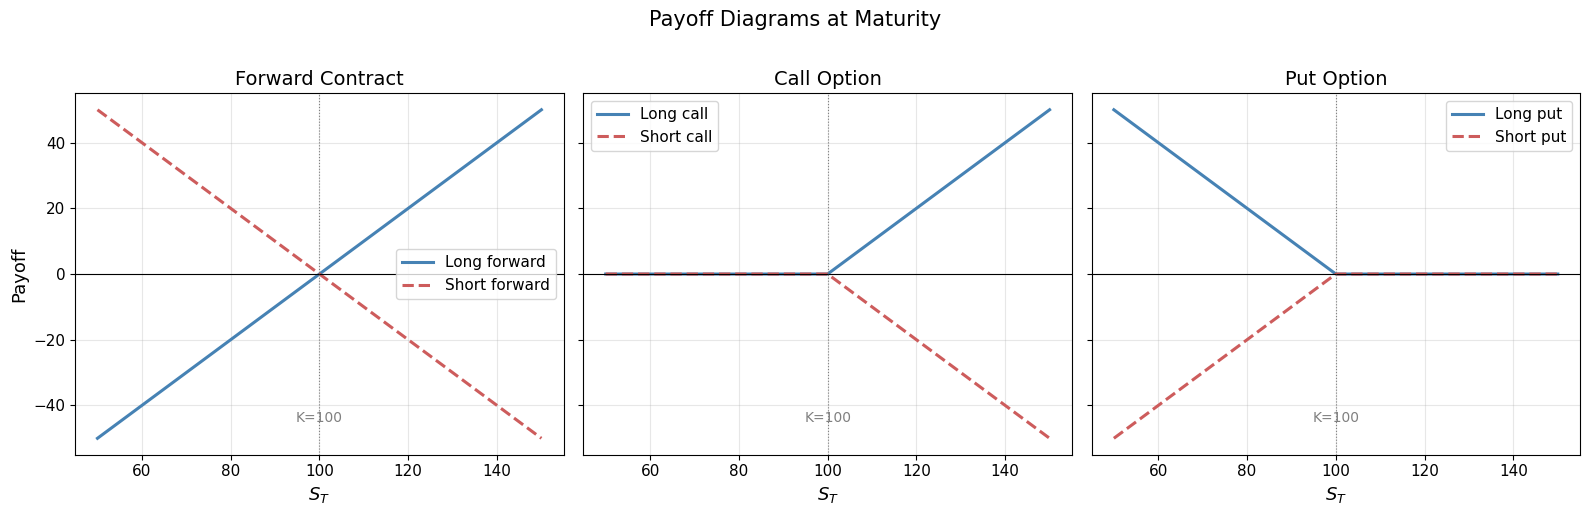

In [5]:
# ============================================================
# Payoff diagrams: forward, call, and put
# ============================================================

K = 100.0   # strike price
ST = np.linspace(50, 150, 500)  # range of spot prices at maturity

# Payoffs at maturity
payoff_long_forward = ST - K
payoff_short_forward = K - ST
payoff_long_call = np.maximum(ST - K, 0)
payoff_short_call = -payoff_long_call
payoff_long_put = np.maximum(K - ST, 0)
payoff_short_put = -payoff_long_put

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# --- Forward ---
ax = axes[0]
ax.plot(ST, payoff_long_forward, color='steelblue', label='Long forward')
ax.plot(ST, payoff_short_forward, color='indianred', linestyle='--', label='Short forward')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(K, color='grey', linewidth=0.8, linestyle=':')
ax.set_title('Forward Contract')
ax.set_xlabel('$S_T$')
ax.set_ylabel('Payoff')
ax.legend()
ax.text(K, -45, f'K={K:.0f}', ha='center', fontsize=10, color='grey')

# --- Call ---
ax = axes[1]
ax.plot(ST, payoff_long_call, color='steelblue', label='Long call')
ax.plot(ST, payoff_short_call, color='indianred', linestyle='--', label='Short call')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(K, color='grey', linewidth=0.8, linestyle=':')
ax.set_title('Call Option')
ax.set_xlabel('$S_T$')
ax.legend()
ax.text(K, -45, f'K={K:.0f}', ha='center', fontsize=10, color='grey')

# --- Put ---
ax = axes[2]
ax.plot(ST, payoff_long_put, color='steelblue', label='Long put')
ax.plot(ST, payoff_short_put, color='indianred', linestyle='--', label='Short put')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(K, color='grey', linewidth=0.8, linestyle=':')
ax.set_title('Put Option')
ax.set_xlabel('$S_T$')
ax.legend()
ax.text(K, -45, f'K={K:.0f}', ha='center', fontsize=10, color='grey')

plt.suptitle('Payoff Diagrams at Maturity', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Key observations:**

- The **forward** payoff is linear and symmetric around $K$: unlimited gain and unlimited loss.
- The **call** has a "hockey stick" shape: zero payoff below $K$, linear gain above $K$.
- The **put** is the mirror image: linear gain below $K$, zero above.
- For every long position there is a short position. Derivatives are **zero-sum games**.

---
## 7. Portfolio Replication and Hedging

### Static replication

A **static replicating portfolio** $\tilde{\pi}$ is constructed at time $t$ **without any rebalancing** such that its payoff at maturity matches that of the target derivative:

$$V_T(\tilde{\pi}) = V_T(\pi) \quad \text{a.s.}$$

By the Law of One Price: $V_t(\pi) = V_t(\tilde{\pi})$ for all $t \leq T$.

**Properties:**
- **Model-independent:** No assumptions about the stock price dynamics are needed.
- **Robust:** Does not depend on volatility $\sigma$, drift $\mu$, or the distribution of returns.
- **Limited:** Only works for certain payoff structures (linear combinations of traded instruments).

### Dynamic replication (preview)

When static replication is not possible, we can construct a portfolio and **continuously rebalance** it to match the derivative's payoff. This is the idea behind **delta hedging** and the **Black-Scholes model**.

- **Model-dependent:** Requires specifying the dynamics of $S_t$ (e.g., geometric Brownian motion).
- **Powerful:** Can price complex, path-dependent options.
- We will develop this rigorously in later lectures.

### Example: Replicating a convertible bond

Consider a simplified **convertible bond** with:
- Maturity $T = 2$ years, zero coupon, face value \$1.
- At maturity, the holder can choose to receive either the bond's face value (\$1) or one share of stock.

**Payoff:** $CB(T) = \max(1, S_T) = 1 + (S_T - 1)^+$

This decomposes into:
- A **zero-coupon bond** paying \$1, plus
- A **European call** with strike $K = 1$.

Therefore:
$$CB(t) = e^{-r(T-t)} + C_t(K=1,\, T)$$

This is a **static replication**: buy a bond and a call, hold to maturity -- no rebalancing needed.

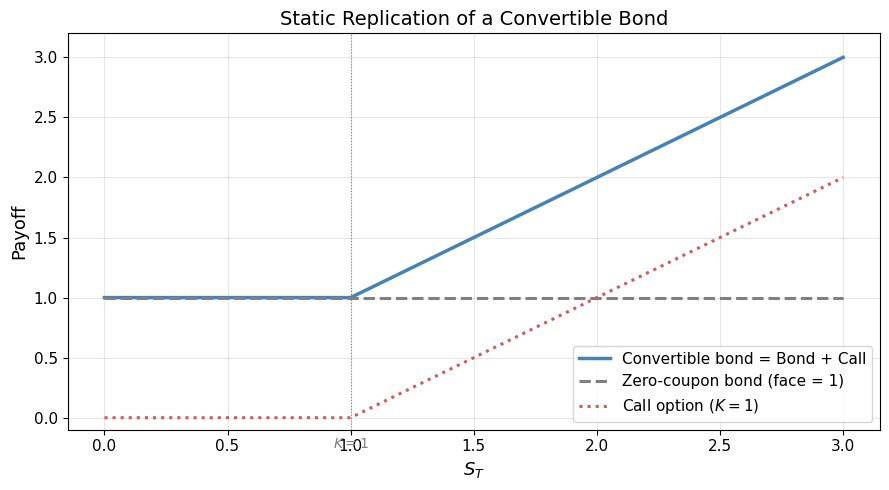

In [6]:
# ============================================================
# Visualise the convertible bond decomposition
# ============================================================

ST_cb = np.linspace(0, 3, 500)
K_cb = 1.0

bond_payoff = np.ones_like(ST_cb) * K_cb
call_payoff = np.maximum(ST_cb - K_cb, 0)
cb_payoff = bond_payoff + call_payoff

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ST_cb, cb_payoff, color='steelblue', linewidth=2.5, label='Convertible bond = Bond + Call')
ax.plot(ST_cb, bond_payoff, color='grey', linestyle='--', label='Zero-coupon bond (face = 1)')
ax.plot(ST_cb, call_payoff, color='indianred', linestyle=':', label='Call option ($K = 1$)')
ax.axvline(K_cb, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('$S_T$')
ax.set_ylabel('Payoff')
ax.set_title('Static Replication of a Convertible Bond')
ax.legend()
ax.set_ylim(-0.1, 3.2)
ax.text(K_cb, -0.25, '$K=1$', ha='center', fontsize=10, color='grey')
plt.tight_layout()
plt.show()

---
## 8. Put-Call Parity

One of the most important results in all of finance -- and it requires **no model** for the underlying asset dynamics.

> **Theorem (Put-Call Parity).** For European options on a non-dividend-paying stock with the same strike $K$ and maturity $T$:
> $$C_t - P_t = S_t - K e^{-r(T-t)}$$

### Proof

Compare two portfolios at time $t$:

| Portfolio | Composition | Value at $t$ |
|-----------|-------------|-------------|
| $\pi_1$ | Long call + short put + $K$ zero-coupon bonds | $C_t - P_t + Ke^{-r(T-t)}$ |
| $\pi_2$ | Long one share of stock | $S_t$ |

At maturity $T$:
$$V_T(\pi_1) = \underbrace{(S_T - K)^+}_{\text{call}} - \underbrace{(K - S_T)^+}_{\text{put}} + K = S_T - K + K = S_T = V_T(\pi_2)$$

where we used the identity $(S_T - K)^+ - (K - S_T)^+ = S_T - K$.

Since $V_T(\pi_1) = V_T(\pi_2)$ almost surely, by the Law of One Price:
$$C_t - P_t + Ke^{-r(T-t)} = S_t$$

Rearranging: $C_t - P_t = S_t - Ke^{-r(T-t)}$. $\square$

### Key properties

- **Model-free:** Holds regardless of the stock price dynamics (no $\sigma$, no $\mu$).
- **Only one degree of freedom:** Given $C_t$, we know $P_t$, and vice versa.
- **Arbitrage test:** Violations of put-call parity signal trading opportunities.
- Holds for **European** options only; American options satisfy inequality bounds.

In [7]:
# ============================================================
# Put-Call Parity verification with numerical example
# ============================================================

# Market data (hypothetical, but realistic)
S = 100.0          # current stock price
K = 100.0          # strike price
r = 0.05           # risk-free rate
T = 0.5            # time to maturity (6 months)
C_market = 7.97    # observed call price
P_market = 5.50    # observed put price

# Put-call parity: C - P should equal S - K*exp(-rT)
lhs = C_market - P_market
rhs = S - K * np.exp(-r * T)

print("Put-Call Parity Verification")
print("=" * 50)
print(f"  Stock price S          = {S:>10.2f}")
print(f"  Strike K               = {K:>10.2f}")
print(f"  Risk-free rate r       = {r:>10.2%}")
print(f"  Time to maturity T     = {T:>10.2f} years")
print(f"  Call price C           = {C_market:>10.2f}")
print(f"  Put price  P           = {P_market:>10.2f}")
print("-" * 50)
print(f"  C - P (LHS)           = {lhs:>10.4f}")
print(f"  S - K*exp(-rT) (RHS)  = {rhs:>10.4f}")
print(f"  Difference (LHS - RHS)= {lhs - rhs:>10.4f}")
print("-" * 50)

tolerance = 0.10
if abs(lhs - rhs) < tolerance:
    print(f"  => Put-call parity holds (within ${tolerance:.2f} tolerance).")
else:
    print(f"  => VIOLATION detected! Arbitrage opportunity of ${abs(lhs - rhs):.4f}.")
    if lhs > rhs:
        print("     Strategy: Sell call, buy put, buy stock, borrow K*exp(-rT).")
    else:
        print("     Strategy: Buy call, sell put, sell stock, invest K*exp(-rT).")

Put-Call Parity Verification
  Stock price S          =     100.00
  Strike K               =     100.00
  Risk-free rate r       =      5.00%
  Time to maturity T     =       0.50 years
  Call price C           =       7.97
  Put price  P           =       5.50
--------------------------------------------------
  C - P (LHS)           =     2.4700
  S - K*exp(-rT) (RHS)  =     2.4690
  Difference (LHS - RHS)=     0.0010
--------------------------------------------------
  => Put-call parity holds (within $0.10 tolerance).


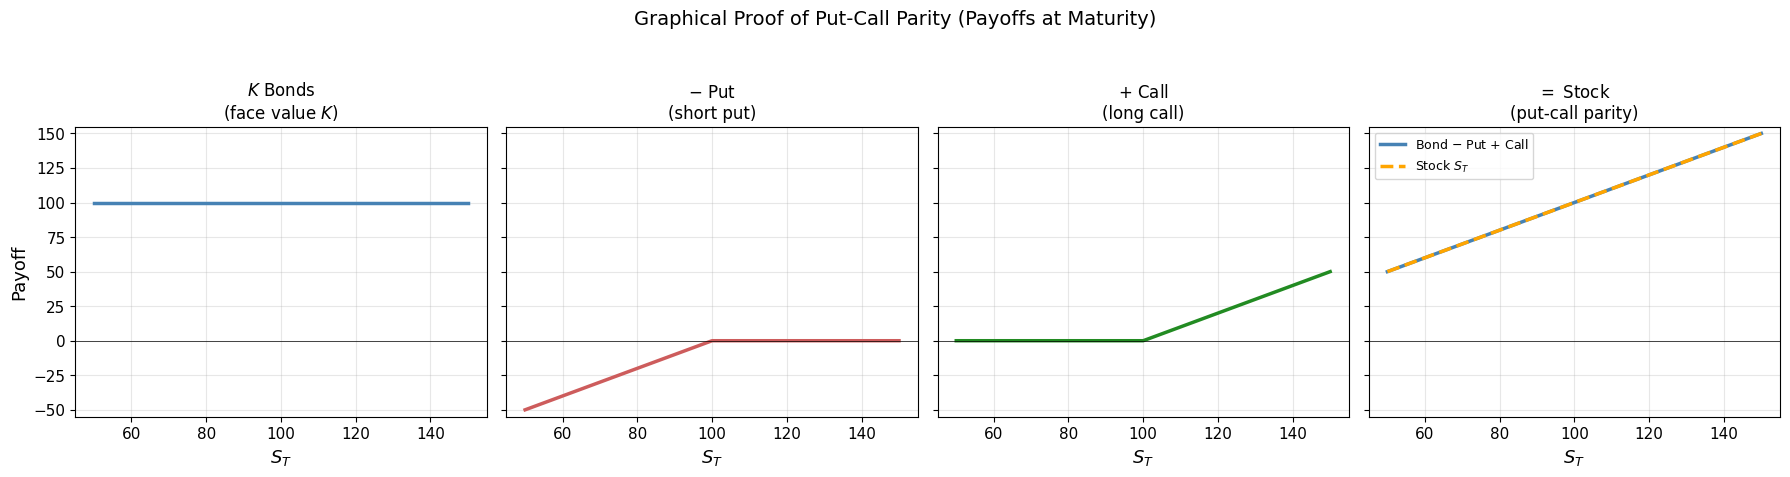

In [8]:
# ============================================================
# Graphical proof of put-call parity
# ============================================================

K = 100.0
ST = np.linspace(50, 150, 500)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)

# Bond
axes[0].plot(ST, np.full_like(ST, K), color='steelblue', linewidth=2.5)
axes[0].set_title('$K$ Bonds\n(face value $K$)', fontsize=12)
axes[0].set_xlabel('$S_T$')
axes[0].set_ylabel('Payoff')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_ylim(-55, 155)

# Minus Put
axes[1].plot(ST, -np.maximum(K - ST, 0), color='indianred', linewidth=2.5)
axes[1].set_title('$-$ Put\n(short put)', fontsize=12)
axes[1].set_xlabel('$S_T$')
axes[1].axhline(0, color='black', linewidth=0.5)

# Plus Call
axes[2].plot(ST, np.maximum(ST - K, 0), color='forestgreen', linewidth=2.5)
axes[2].set_title('$+$ Call\n(long call)', fontsize=12)
axes[2].set_xlabel('$S_T$')
axes[2].axhline(0, color='black', linewidth=0.5)

# Result = Stock
combined = K - np.maximum(K - ST, 0) + np.maximum(ST - K, 0)
axes[3].plot(ST, combined, color='steelblue', linewidth=2.5, label='Bond $-$ Put $+$ Call')
axes[3].plot(ST, ST, color='orange', linewidth=2.5, linestyle='--', label='Stock $S_T$')
axes[3].set_title('$=$ Stock\n(put-call parity)', fontsize=12)
axes[3].set_xlabel('$S_T$')
axes[3].legend(fontsize=9)
axes[3].axhline(0, color='black', linewidth=0.5)

plt.suptitle('Graphical Proof of Put-Call Parity (Payoffs at Maturity)', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

The four panels show that: $K \text{ bonds} - \text{Put} + \text{Call} = \text{Stock}$.

Rearranging: $\text{Call} - \text{Put} = \text{Stock} - K \text{ bonds}$, which is exactly put-call parity at the payoff level. Discounting gives us the price relationship.

---
## 9. Risk-Neutral Pricing: Intuition

We have seen that derivative prices are determined by **replication**, not by expectations under the real-world probability measure $\mathbb{P}$.

But there is an elegant alternative viewpoint. It turns out that in a complete, arbitrage-free market, there exists a special probability measure $\mathbb{Q}$ -- called the **risk-neutral measure** -- such that:

$$V_t = e^{-r(T-t)} \, \mathbb{E}^{\mathbb{Q}}\!\left[\, H \,\middle|\, \mathcal{F}_t \right]$$

where $H = h(S_T)$ is the derivative's payoff.

### What makes $\mathbb{Q}$ special?

Under $\mathbb{Q}$, all traded assets earn the risk-free rate $r$ in expectation:
$$\mathbb{E}^{\mathbb{Q}}[S_T \mid \mathcal{F}_t] = S_t \, e^{r(T-t)}$$

This does **not** mean investors are actually risk-neutral. Rather, the risk premium is already embedded in the measure change from $\mathbb{P}$ to $\mathbb{Q}$.

### Key theorems (previewed here, to be proved later)

| Theorem | Statement |
|---------|----------|
| **First Fundamental Theorem** | Market is arbitrage-free $\Leftrightarrow$ $\exists$ an equivalent martingale measure $\mathbb{Q}$ |
| **Second Fundamental Theorem** | Market is complete $\Leftrightarrow$ $\mathbb{Q}$ is unique |

We will develop these ideas rigorously starting from the binomial model in Lecture 2.

---
## 10. Building a Replicating Portfolio: A Numerical Example

Let us bring together the ideas of replication and no-arbitrage with a concrete example.

### Setting

Suppose the current stock price is $S_0 = 100$. In one period, it can go **up** to $S_u = 120$ or **down** to $S_d = 85$. The risk-free rate is $r = 5\%$ (per period, simple compounding for this discrete example).

We want to price a **European call option** with strike $K = 100$.

**Payoffs:**
- If $S_u = 120$: $C_u = \max(120 - 100, 0) = 20$
- If $S_d = 85$: $C_d = \max(85 - 100, 0) = 0$

### Replicating portfolio

We look for a portfolio of $\Delta$ shares and $B$ dollars in the bond such that:

$$\Delta \cdot S_u + B \cdot (1+r) = C_u \quad \text{and} \quad \Delta \cdot S_d + B \cdot (1+r) = C_d$$

Solving:
$$\Delta = \frac{C_u - C_d}{S_u - S_d}, \qquad B = \frac{C_d - \Delta \cdot S_d}{1+r}$$

The no-arbitrage price of the call is:
$$C_0 = \Delta \cdot S_0 + B$$

In [9]:
# ============================================================
# One-period binomial replication
# ============================================================

S0 = 100.0    # current stock price
Su = 120.0    # stock price in "up" state
Sd = 85.0     # stock price in "down" state
K  = 100.0    # strike
r  = 0.05     # one-period risk-free rate (simple)

# Option payoffs
Cu = max(Su - K, 0)   # call payoff in up state
Cd = max(Sd - K, 0)   # call payoff in down state

# Replicating portfolio
Delta = (Cu - Cd) / (Su - Sd)
B = (Cd - Delta * Sd) / (1 + r)

# No-arbitrage call price
C0 = Delta * S0 + B

print("One-Period Binomial Replication")
print("=" * 50)
print(f"  S0 = {S0:.2f},  Su = {Su:.2f},  Sd = {Sd:.2f}")
print(f"  K  = {K:.2f},   r  = {r:.2%}")
print(f"  Cu = {Cu:.2f},  Cd = {Cd:.2f}")
print("-" * 50)
print(f"  Delta (shares)         = {Delta:.6f}")
print(f"  B (bond investment)    = {B:.6f}")
print(f"  Call price C0          = {C0:.6f}")
print()

# Verify replication
portfolio_up   = Delta * Su + B * (1 + r)
portfolio_down = Delta * Sd + B * (1 + r)
print("Verification (replicating portfolio payoffs):")
print(f"  Up state:   Delta*Su + B*(1+r) = {portfolio_up:.6f}  (should be {Cu:.2f})")
print(f"  Down state: Delta*Sd + B*(1+r) = {portfolio_down:.6f}  (should be {Cd:.2f})")

One-Period Binomial Replication
  S0 = 100.00,  Su = 120.00,  Sd = 85.00
  K  = 100.00,   r  = 5.00%
  Cu = 20.00,  Cd = 0.00
--------------------------------------------------
  Delta (shares)         = 0.571429
  B (bond investment)    = -46.258503
  Call price C0          = 10.884354

Verification (replicating portfolio payoffs):
  Up state:   Delta*Su + B*(1+r) = 20.000000  (should be 20.00)
  Down state: Delta*Sd + B*(1+r) = 0.000000  (should be 0.00)


In [10]:
# ============================================================
# Risk-neutral pricing: same answer, different perspective
# ============================================================

# Risk-neutral probability of up move
q = ((1 + r) * S0 - Sd) / (Su - Sd)

# Risk-neutral call price
C0_rn = (q * Cu + (1 - q) * Cd) / (1 + r)

print("Risk-Neutral Pricing")
print("=" * 50)
print(f"  Risk-neutral prob (up)  q     = {q:.6f}")
print(f"  Risk-neutral prob (down) 1-q  = {1-q:.6f}")
print(f"  E^Q[C] / (1+r)               = {C0_rn:.6f}")
print(f"  Replication price             = {C0:.6f}")
print(f"  Match?  {np.isclose(C0, C0_rn)}")
print()
print("Key insight: The real-world probability p of the up move does NOT")
print("appear anywhere in the pricing formula. Only q (risk-neutral) matters.")

Risk-Neutral Pricing
  Risk-neutral prob (up)  q     = 0.571429
  Risk-neutral prob (down) 1-q  = 0.428571
  E^Q[C] / (1+r)               = 10.884354
  Replication price             = 10.884354
  Match?  True

Key insight: The real-world probability p of the up move does NOT
appear anywhere in the pricing formula. Only q (risk-neutral) matters.


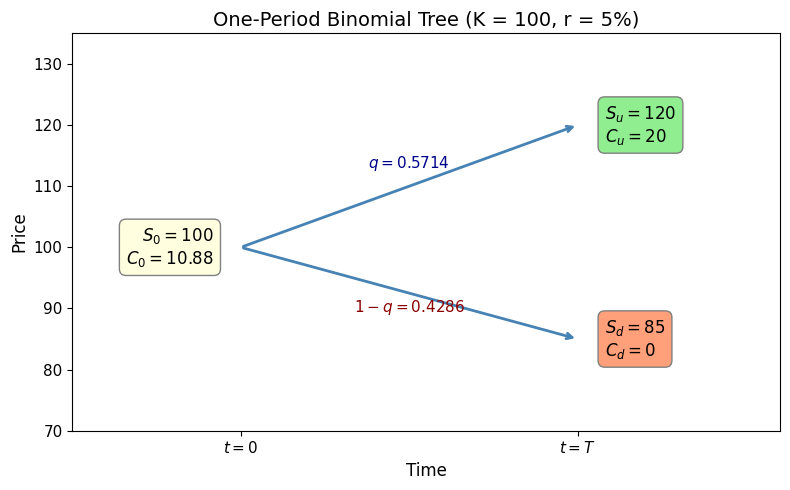

In [11]:
# ============================================================
# Visualise the one-period binomial tree
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

# Stock tree
ax.annotate('', xy=(1.0, Su), xytext=(0.0, S0),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
ax.annotate('', xy=(1.0, Sd), xytext=(0.0, S0),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))

# Node labels
offset = 3
ax.text(-0.08, S0, f'$S_0 = {S0:.0f}$\n$C_0 = {C0:.2f}$',
        fontsize=12, ha='right', va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='grey'))

ax.text(1.08, Su, f'$S_u = {Su:.0f}$\n$C_u = {Cu:.0f}$',
        fontsize=12, ha='left', va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgreen', edgecolor='grey'))

ax.text(1.08, Sd, f'$S_d = {Sd:.0f}$\n$C_d = {Cd:.0f}$',
        fontsize=12, ha='left', va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightsalmon', edgecolor='grey'))

# Probability labels
ax.text(0.5, (S0 + Su)/2 + 3, f'$q = {q:.4f}$', fontsize=11,
        ha='center', color='darkblue')
ax.text(0.5, (S0 + Sd)/2 - 3, f'$1-q = {1-q:.4f}$', fontsize=11,
        ha='center', color='darkred')

ax.set_xlim(-0.5, 1.6)
ax.set_ylim(70, 135)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Price', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['$t = 0$', '$t = T$'])
ax.set_title(f'One-Period Binomial Tree (K = {K:.0f}, r = {r:.0%})', fontsize=14)
ax.grid(False)
plt.tight_layout()
plt.show()

---
## 11. Profit-and-Loss Diagrams (Including the Premium)

The **payoff diagram** shows the gross payoff at maturity. But the option buyer pays a premium upfront. The **profit-and-loss (P&L) diagram** subtracts the future value of the premium to show the net gain/loss.

For a call purchased at price $C_0$:
$$\text{P\&L} = (S_T - K)^+ - C_0 \cdot e^{rT}$$

The **breakeven** stock price is $S_T^* = K + C_0 \cdot e^{rT}$.

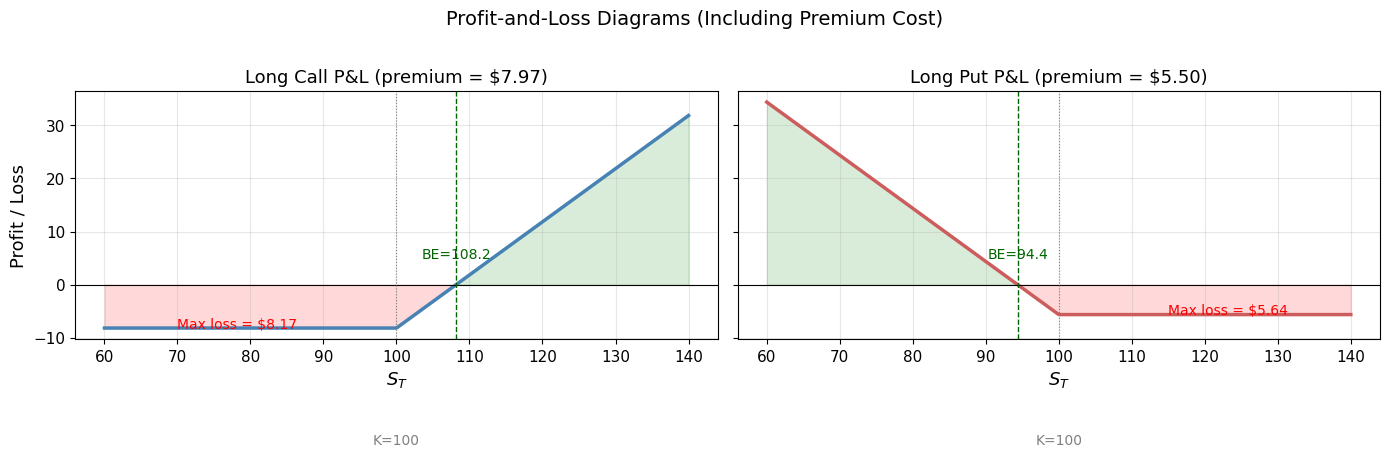

In [12]:
# ============================================================
# Profit-and-Loss diagrams for call and put
# ============================================================

K = 100.0
r = 0.05
T = 0.5
C_premium = 7.97    # call premium paid today
P_premium = 5.50    # put premium paid today

ST = np.linspace(60, 140, 500)

# Future value of premiums (cost of financing)
C_fv = C_premium * np.exp(r * T)
P_fv = P_premium * np.exp(r * T)

# P&L
pnl_long_call = np.maximum(ST - K, 0) - C_fv
pnl_long_put  = np.maximum(K - ST, 0) - P_fv

# Breakeven points
call_breakeven = K + C_fv
put_breakeven  = K - P_fv

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Long call P&L
ax = axes[0]
ax.plot(ST, pnl_long_call, color='steelblue', linewidth=2.5)
ax.fill_between(ST, pnl_long_call, 0, where=(pnl_long_call > 0),
                alpha=0.15, color='green')
ax.fill_between(ST, pnl_long_call, 0, where=(pnl_long_call < 0),
                alpha=0.15, color='red')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(K, color='grey', linewidth=0.8, linestyle=':')
ax.axvline(call_breakeven, color='darkgreen', linewidth=1, linestyle='--')
ax.set_title(f'Long Call P&L (premium = ${C_premium:.2f})', fontsize=13)
ax.set_xlabel('$S_T$')
ax.set_ylabel('Profit / Loss')
ax.text(K, -30, f'K={K:.0f}', ha='center', fontsize=10, color='grey')
ax.text(call_breakeven, 5, f'BE={call_breakeven:.1f}', ha='center',
        fontsize=10, color='darkgreen')
ax.annotate(f'Max loss = ${C_fv:.2f}', xy=(70, -C_fv), fontsize=10,
            color='red')

# Long put P&L
ax = axes[1]
ax.plot(ST, pnl_long_put, color='indianred', linewidth=2.5)
ax.fill_between(ST, pnl_long_put, 0, where=(pnl_long_put > 0),
                alpha=0.15, color='green')
ax.fill_between(ST, pnl_long_put, 0, where=(pnl_long_put < 0),
                alpha=0.15, color='red')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(K, color='grey', linewidth=0.8, linestyle=':')
ax.axvline(put_breakeven, color='darkgreen', linewidth=1, linestyle='--')
ax.set_title(f'Long Put P&L (premium = ${P_premium:.2f})', fontsize=13)
ax.set_xlabel('$S_T$')
ax.text(K, -30, f'K={K:.0f}', ha='center', fontsize=10, color='grey')
ax.text(put_breakeven, 5, f'BE={put_breakeven:.1f}', ha='center',
        fontsize=10, color='darkgreen')
ax.annotate(f'Max loss = ${P_fv:.2f}', xy=(115, -P_fv), fontsize=10,
            color='red')

plt.suptitle('Profit-and-Loss Diagrams (Including Premium Cost)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**

- The **maximum loss** for a long option position is the (future-valued) premium paid.
- The **breakeven** price is $K + C_0 e^{rT}$ for a call and $K - P_0 e^{rT}$ for a put.
- Beyond the breakeven, every dollar of favourable stock movement translates directly to profit.

---
## 12. Option Strategy: Protective Put

Combining options with the underlying creates structured risk profiles. A classic example:

**Protective put** = Long stock + Long put (same strike $K$).

$$\text{Payoff} = S_T + (K - S_T)^+ = \max(S_T,\, K)$$

This provides **downside protection**: the portfolio value can never fall below $K$, while retaining full upside participation.

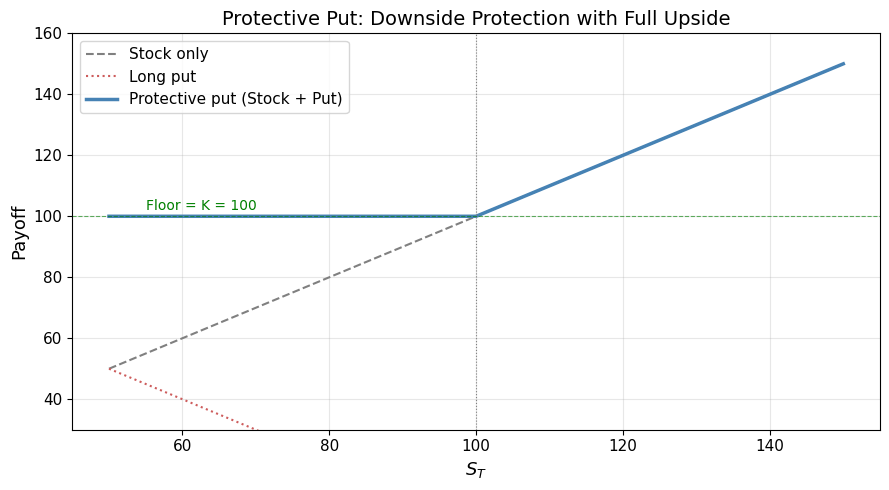

In [13]:
# ============================================================
# Protective put payoff diagram
# ============================================================

K = 100.0
ST = np.linspace(50, 150, 500)

stock_payoff = ST
put_payoff = np.maximum(K - ST, 0)
protective_put = stock_payoff + put_payoff  # = max(ST, K)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ST, stock_payoff, color='grey', linestyle='--', linewidth=1.5,
        label='Stock only')
ax.plot(ST, put_payoff, color='indianred', linestyle=':', linewidth=1.5,
        label='Long put')
ax.plot(ST, protective_put, color='steelblue', linewidth=2.5,
        label='Protective put (Stock + Put)')
ax.axhline(K, color='green', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(K, color='grey', linewidth=0.8, linestyle=':')
ax.text(55, K + 2, f'Floor = K = {K:.0f}', fontsize=10, color='green')
ax.set_xlabel('$S_T$')
ax.set_ylabel('Payoff')
ax.set_title('Protective Put: Downside Protection with Full Upside')
ax.legend(loc='upper left')
ax.set_ylim(30, 160)
plt.tight_layout()
plt.show()

Note: By put-call parity, the protective put (Stock + Put) has the same payoff structure as a Bond + Call. This is another illustration of the parity relationship.

---
## 13. Summary of Key Formulas

| Concept | Formula |
|---------|--------|
| Discount factor | $D(t,T) = e^{-r(T-t)}$ |
| Forward price (no dividends) | $F_{t,T} = S_t \, e^{r(T-t)}$ |
| Forward price (dividend yield $q$) | $F_{t,T} = S_t \, e^{(r-q)(T-t)}$ |
| Call payoff | $C(S_T, K) = (S_T - K)^+ = \max(0, S_T - K)$ |
| Put payoff | $P(S_T, K) = (K - S_T)^+ = \max(0, K - S_T)$ |
| Put-call parity | $C_t - P_t = S_t - K e^{-r(T-t)}$ |
| Binomial replicating delta | $\Delta = \frac{C_u - C_d}{S_u - S_d}$ |
| Risk-neutral probability (binomial) | $q = \frac{(1+r)S_0 - S_d}{S_u - S_d}$ |
| Risk-neutral pricing | $V_0 = e^{-rT} \, \mathbb{E}^{\mathbb{Q}}[H]$ |

---
## Exercises

### Exercise 1: Forward Pricing (Guided)

A stock currently trades at $S_0 = 150$. The continuously compounded risk-free rate is $r = 3\%$ per annum and the stock pays a continuous dividend yield of $q = 1.5\%$.

**(a)** Compute the 6-month forward price.

**(b)** If the market quotes the forward at $F_{\text{market}} = 152$, describe the arbitrage strategy and compute the risk-free profit (in present value terms).

**(c)** Plot the forward price $F_{0,T}$ as a function of $T \in [0, 5]$ for both $q = 0$ and $q = 1.5\%$.

**Hint:** Use the formula $F_{0,T} = S_0 \, e^{(r-q)T}$.

0.8707706833199325


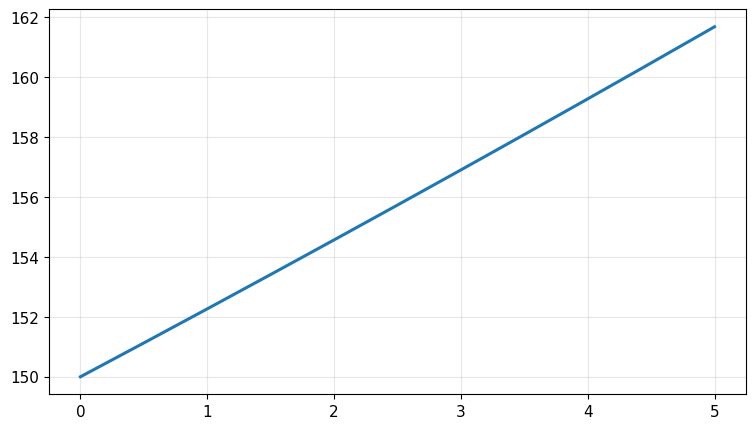

In [18]:
# ============================================================
# Exercise 1 -- Starter code
# ============================================================

S0_ex = 150.0
r_ex  = 0.03
q_ex  = 0.015
T_ex  = 0.5

# (a) Compute the 6-month forward price
F_6m = S0_ex*np.exp((r_ex-q_ex)*T_ex)
# print(f"6-month forward price: {F_6m:.4f}")

# (b) Arbitrage analysis
F_market_ex = 152.0
print(F_market_ex-F_6m)

# (c) Plot F(0,T) for T in [0, 5]
T_range = np.linspace(0, 5, 300)
plt.plot(T_range,S0_ex*np.exp((r_ex-q_ex)*T_range))
plt.show()

### Exercise 2: Put-Call Parity (Intermediate)

The following European options on stock XYZ are observed in the market (same maturity $T = 1$ year, risk-free rate $r = 4\%$):

| Strike $K$ | Call price $C$ | Put price $P$ | Stock price $S$ |
|-----------|---------------|--------------|----------------|
| 90 | 18.50 | 5.05 | 105 |
| 100 | 13.20 | 8.80 | 105 |
| 110 | 8.90 | 12.50 | 105 |

**(a)** For each strike, check whether put-call parity holds. Compute $C - P$ and $S - Ke^{-rT}$ and compare.

**(b)** If any row violates put-call parity, describe the arbitrage strategy and compute the profit.

**Hint:** The tolerance for real markets is typically a few cents due to bid-ask spreads.

In [28]:
# ============================================================
# Exercise 2 -- Starter code
# ============================================================

S_ex2 = 105.0
r_ex2 = 0.04
T_ex2 = 1.0

strikes   = [90,    100,   110]
calls     = [18.50, 13.20, 8.90]
puts      = [5.05,  8.80,  12.50]

print(f"{'K':>6} {'C-P':>10} {'S-K*exp(-rT)':>14} {'Difference':>12} {'Arbitrage?':>12}")
print("-" * 60)
lhs = []
rhs = []
for K_i, C_i, P_i in zip(strikes, calls, puts):
    lhs_i = C_i - P_i
    rhs_i = S_ex2 - K_i * np.exp(-r_ex2 * T_ex2)
    lhs.append(lhs_i)
    rhs.append(rhs_i)
    diff_i = lhs_i - rhs_i
    arb = "YES" if abs(diff_i) > 0.10 else "No"
    print(f"{K_i:>6.0f} {lhs_i:>10.4f} {rhs_i:>14.4f} {diff_i:>12.4f} {arb:>12}")

# (b) For any violations, describe and compute arbitrage profit below:
for l,r,K_i in zip(lhs,rhs,strikes):
    print(l)
    print(r)
    if l < r:
        print(f"Buy Call, sell Put; Sell stock, buy ZCB at K={K_i}, profit {r-l}")
    elif l > r:
        print(f"Sell Call, buy Put; Buy stock, sell ZCB at K={K_i}, profit {l-r}")



     K        C-P   S-K*exp(-rT)   Difference   Arbitrage?
------------------------------------------------------------
    90    13.4500        18.5290      -5.0790          YES
   100     4.4000         8.9211      -4.5211          YES
   110    -3.6000        -0.6868      -2.9132          YES
13.45
18.528950476290916
Buy Call, sell Put; Sell stock, buy ZCB at K=90, profit 5.078950476290917
4.399999999999999
8.921056084767685
Buy Call, sell Put; Sell stock, buy ZCB at K=100, profit 4.521056084767686
-3.5999999999999996
-0.686838306755547
Buy Call, sell Put; Sell stock, buy ZCB at K=110, profit 2.9131616932444526


### Exercise 3: Binomial Pricing (Intermediate)

Using the one-period binomial model with $S_0 = 50$, $u = 1.3$ (so $S_u = 65$), $d = 0.8$ (so $S_d = 40$), and $r = 6\%$ (simple, per period):

**(a)** Price a European **put** option with strike $K = 55$ using replication (find $\Delta$ and $B$).

**(b)** Verify your answer using risk-neutral pricing.

**(c)** Check that put-call parity holds for your binomial call and put prices.

**Hint:** For the put, $P_u = \max(K - S_u, 0)$ and $P_d = \max(K - S_d, 0)$.

We look for a portfolio of $\Delta$ shares and $B$ dollars in the bond such that:

$$\Delta \cdot S_u + B \cdot (1+r) = P_u \quad \text{and} \quad \Delta \cdot S_d + B \cdot (1+r) = P_u$$

Solving:
$$\Delta = \frac{P_u - P_d}{S_u - S_d}, \qquad B = \frac{P_d - \Delta \cdot S_d}{1+r}$$

The no-arbitrage price of the put is:
$$P_0 = \Delta \cdot S_0 + B$$

$$\Delta S_u + B(1+r) = P_u=\max{K-S_u,0} \quad \Delta S_d + B(1+r) = P_d \max{K-S_d,0}$$

which yields:

$\Delta(S_u-S_d) = P_u -P_d$  i.e. $\Delta = (P_u - P_d)/(S_u-S_d)$

and $ B = (P_u-\Delta S_u)/(1+r)$


In [56]:
# ============================================================
# Exercise 3 -- Starter code
# ============================================================

S0_ex3 = 50.0
u_ex3  = 1.3
d_ex3  = 0.8
r_ex3  = 0.06
K_ex3  = 55.0

Su_ex3 = S0_ex3 * u_ex3
Sd_ex3 = S0_ex3 * d_ex3

# (a) Replicate the put
Pu = np.maximum(K_ex3 - Su_ex3,0)
Pd = np.maximum(K_ex3 - Sd_ex3,0)
Delta_put = (Pu-Pd)/(Su_ex3-Sd_ex3)
B_put = (Pu-Delta_put*Su_ex3)/(1+r_ex3)
P0 = Delta_put*S0_ex3+B_put

# (b) Risk-neutral pricing
q_ex3 = ((1+r_ex3)*S0_ex3-Sd_ex3)/(Su_ex3-Sd_ex3)
P0_rn = (q_ex3*Pu+(1-q_ex3)*Pd)/(1+r_ex3)

print(np.abs(P0-P0_rn))
# (c) Put-call parity check
# First price the call, then check C - P = S - K/(1+r)
C0_rn  = (q_ex3*np.maximum(Su_ex3-K_ex3,0)+(1-q_ex3)*np.maximum(Sd_ex3-K_ex3,0))/(1+r_ex3)

print(C0_rn-P0_rn)
print(S0_ex3-K_ex3/(1+r_ex3))

8.881784197001252e-16
-1.8867924528301883
-1.8867924528301856


### Exercise 4: Option Strategies (Open-Ended)

A **straddle** is the combination of a long call and a long put with the same strike and maturity.

**(a)** Write down the payoff formula for a straddle: $\text{Straddle}(S_T) = \ldots$

**(b)** Plot the payoff and P&L diagrams for a straddle with $K = 100$, $C_0 = 8$, $P_0 = 6$, $r = 5\%$, $T = 0.5$ years.

**(c)** Under what market view would you buy a straddle? Under what view would you sell one?

**(d)** *Challenge:* A **strangle** uses different strikes: long put with $K_1 < K$ and long call with $K_2 > K$. How does the payoff compare to a straddle? Plot both on the same axes.

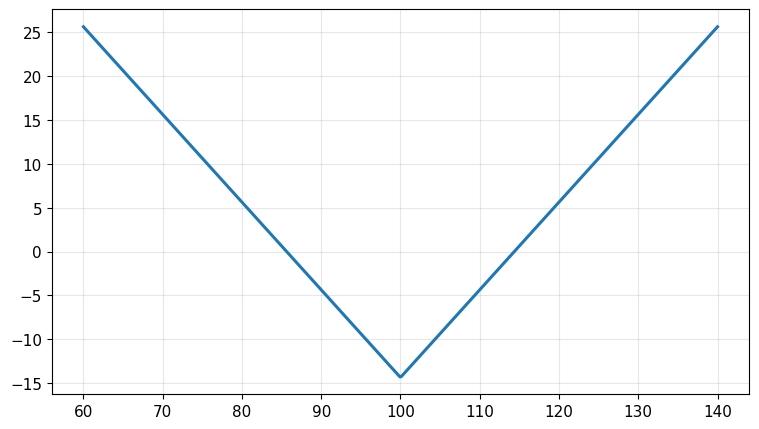

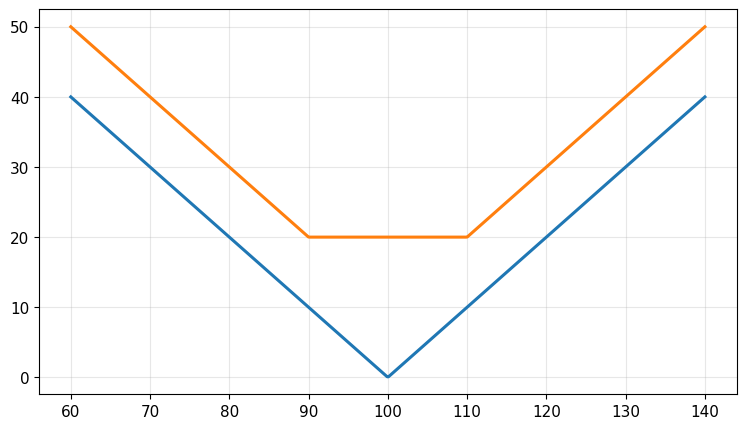

In [63]:
# ============================================================
# Exercise 4 -- Starter code
# ============================================================

K_ex4 = 100.0
C0_ex4 = 8.0
P0_ex4 = 6.0
r_ex4 = 0.05
T_ex4 = 0.5
ST_ex4 = np.linspace(60, 140, 500)

# (a) and (b): Compute and plot straddle payoff and P&L
straddle_payoff = np.maximum(ST_ex4-K_ex4,0)+ np.maximum(K_ex4-ST_ex4,0)
straddle_pnl = straddle_payoff-(C0_ex4+P0_ex4)*np.exp(r_ex4*T_ex4)
plt.plot(ST_ex4,straddle_pnl)
plt.show()

# (c) --> think volatility is going to be HIGH

# (d) Challenge: strangle with K1 = 90, K2 = 110
straddle_payoff2 = np.maximum(ST_ex4-(K_ex4-10),0)+ np.maximum((K_ex4+10)-ST_ex4,0)
plt.plot(ST_ex4,straddle_payoff)
plt.plot(ST_ex4,straddle_payoff2)

plt.show()

---
## Key Takeaways

1. **Financial engineering** prices derivatives by **replication**, not by forecasting returns. The price of a derivative equals the cost of replicating its payoff.

2. The **no-arbitrage principle** is the cornerstone: if two portfolios have identical future payoffs, they must have the same price today (Law of One Price).

3. **Forward prices** follow from a simple cost-of-carry argument: $F_{0,T} = S_0 e^{rT}$. No probability model is needed.

4. **Put-call parity** ($C - P = S - Ke^{-rT}$) is **model-free** -- it holds for any stock dynamics, requiring only no-arbitrage.

5. In the **one-period binomial model**, we can exactly replicate any option payoff with a portfolio of $\Delta$ shares and $B$ bonds. The resulting price is unique.

6. **Risk-neutral pricing** gives the same answer as replication: $V_0 = \frac{1}{1+r}\mathbb{E}^{\mathbb{Q}}[H]$. The real-world probability does not appear.

7. **Options** have asymmetric payoffs (limited downside, potentially large upside), which is why they have positive prices.

---

**Next lecture:** We will develop the **binomial model** in detail -- multi-period trees, risk-neutral probabilities, and convergence to the Black-Scholes formula.